### Import necessary library

In [285]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from util.parse_loc import parse_forecast_file

### Load The DataFrame from the models forecasted folder

In [286]:
forecast_folder = Path("forecast_price") / "LSTM"

crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [287]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 2.91
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


### Normalized the data for each crops

In [288]:
for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

In [289]:
def find_intersections(dates1, prices1, dates2, prices2):
    """
    Find intersection points between two price curves
    """
    intersections = []

    # Find common dates between the two datasets
    common_dates = []
    common_prices1 = []
    common_prices2 = []

    for i, date1 in enumerate(dates1):
        if date1 in dates2:
            j = dates2.index(date1)
            common_dates.append(date1)
            common_prices1.append(prices1[i])
            common_prices2.append(prices2[j])

    # Find sign changes in price differences (indicates intersection)
    for i in range(len(common_prices1) - 1):
        diff1 = common_prices1[i] - common_prices2[i]
        diff2 = common_prices1[i + 1] - common_prices2[i + 1]

        # Check if there's a sign change (intersection)
        if diff1 * diff2 < 0:
            # Linear interpolation to find exact intersection point
            t = abs(diff1) / (abs(diff1) + abs(diff2))
            intersect_date = (
                common_dates[i] + (common_dates[i + 1] - common_dates[i]) * t
            )
            intersect_price = (
                common_prices1[i] + (common_prices1[i + 1] - common_prices1[i]) * t
            )

            intersections.append((intersect_date, intersect_price))

    return intersections

In [290]:
# Configuration and styling
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fill_colors = colors
line_styles = ["-"] * 4


def calculate_statistics(crop_data):
    """Calculate comprehensive statistics for all crops"""
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    stats = {
        "avg_normalized": np.mean(all_prices),
        "std_normalized": np.std(all_prices),
        "num_crops": len(crop_data),
    }
    return stats, all_prices


def plot_crop_lines(ax, crop_data, colors, fill_colors):
    """Plot crop price lines with fill areas"""
    for i, (crop_name, data) in enumerate(crop_data.items()):
        ax.plot(
            data["dates"],
            data["prices"],
            color=colors[i],
            linewidth=2.5,
            marker="o",
            markersize=6,
            label=crop_name,
            alpha=0.9,
        )
        # Fill between removed to eliminate fill color under the graphs


def plot_intersections(ax, crop_data):
    """Find and plot intersection points"""
    crop_names = list(crop_data.keys())
    intersection_info = []

    for i in range(len(crop_names)):
        for j in range(i + 1, len(crop_names)):
            crop1, crop2 = crop_names[i], crop_names[j]
            intersections = find_intersections(
                crop_data[crop1]["dates"],
                crop_data[crop1]["prices"],
                crop_data[crop2]["dates"],
                crop_data[crop2]["prices"],
            )

            for date, price in intersections:
                ax.plot(
                    date,
                    price,
                    "o",
                    markersize=12,
                    markerfacecolor="yellow",
                    markeredgecolor="black",
                    zorder=10,
                    alpha=0.6,
                )
                # Text annotation for intersection points removed
                intersection_info.append(
                    {"crop1": crop1, "crop2": crop2, "date": date, "price": price}
                )

    return intersection_info


def style_plot(ax, title, xlabel, ylabel):
    """Apply consistent styling to plot"""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(
        loc="upper right",
    )
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

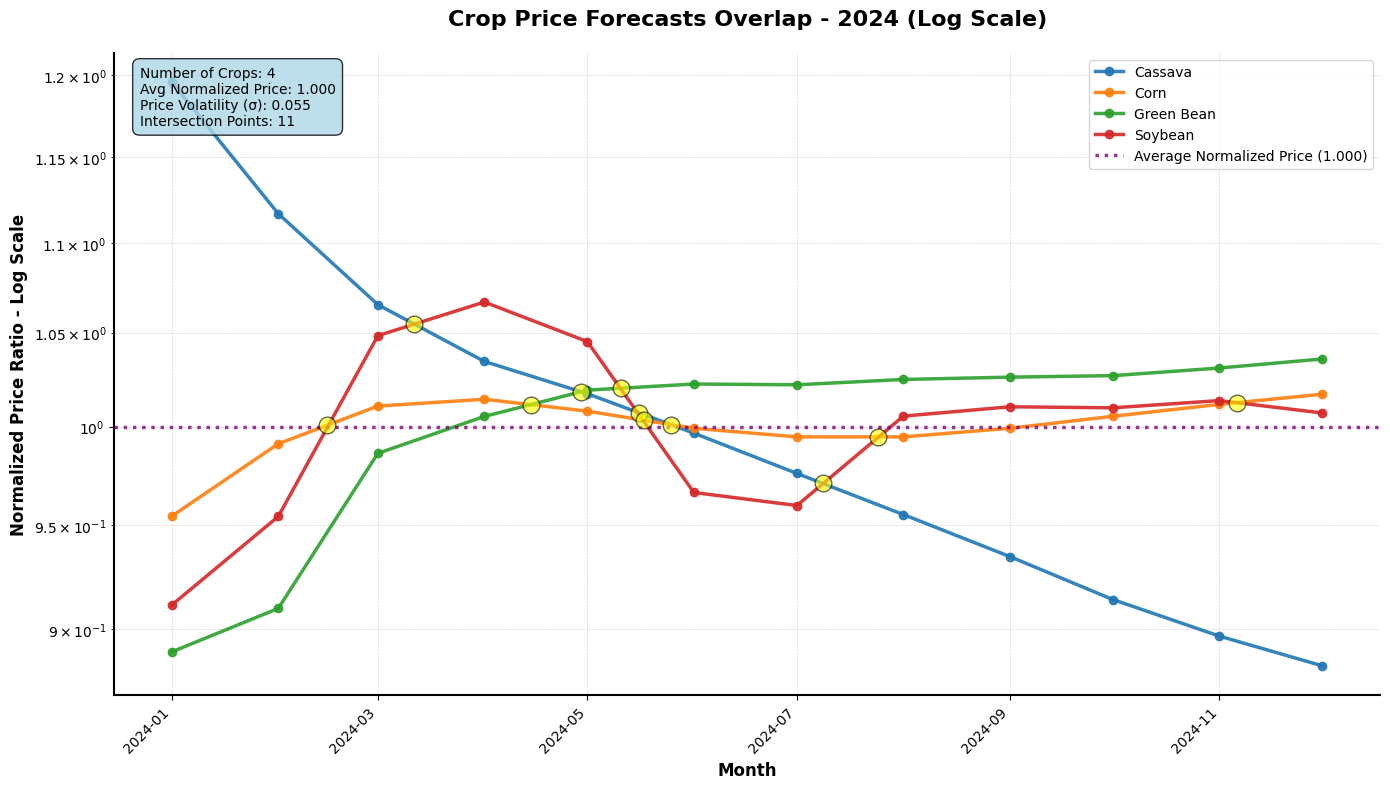

In [291]:
# Main plotting function
def create_crop_analysis_plot():
    """Create comprehensive crop price analysis plot"""
    stats, all_prices = calculate_statistics(crop_data)

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    # Plot crop lines and fill areas
    plot_crop_lines(ax, crop_data, colors, fill_colors)

    # Plot intersection points
    intersection_info = plot_intersections(ax, crop_data)

    # Add average price line
    avg_price = stats["avg_normalized"]
    ax.axhline(
        y=avg_price,
        color="purple",
        linestyle=":",
        linewidth=2.5,
        label=f"Average Normalized Price ({avg_price:.3f})",
        alpha=0.8,
        zorder=5,
    )

    # Set log scale and styling
    ax.set_yscale("log")
    style_plot(
        ax,
        "Crop Price Forecasts Overlap - 2024 (Log Scale)",
        "Month",
        "Normalized Price Ratio - Log Scale",
    )

    # Add statistics text box
    stats_text = (
        f"Number of Crops: {stats['num_crops']}\n"
        f"Avg Normalized Price: {stats['avg_normalized']:.3f}\n"
        f"Price Volatility (σ): {stats['std_normalized']:.3f}\n"
        f"Intersection Points: {len(intersection_info)}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return intersection_info


intersection_info = create_crop_analysis_plot()

In [292]:
time_grow = {"Cassava": 250, "Corn": 100, "Green Bean": 80, "Soybean": 90}
crops_yield_per_rai = {"Cassava": 3500, "Corn": 2500, "Green Bean": 245, "Soybean": 300}

### Gantt chart: Planting to Harvest windows aligned to peak prices

This chart shows, for each crop, planting-to-harvest windows whose harvest dates align with forecasted local peak prices. Stars mark the peak-harvest dates (optimal sell times).

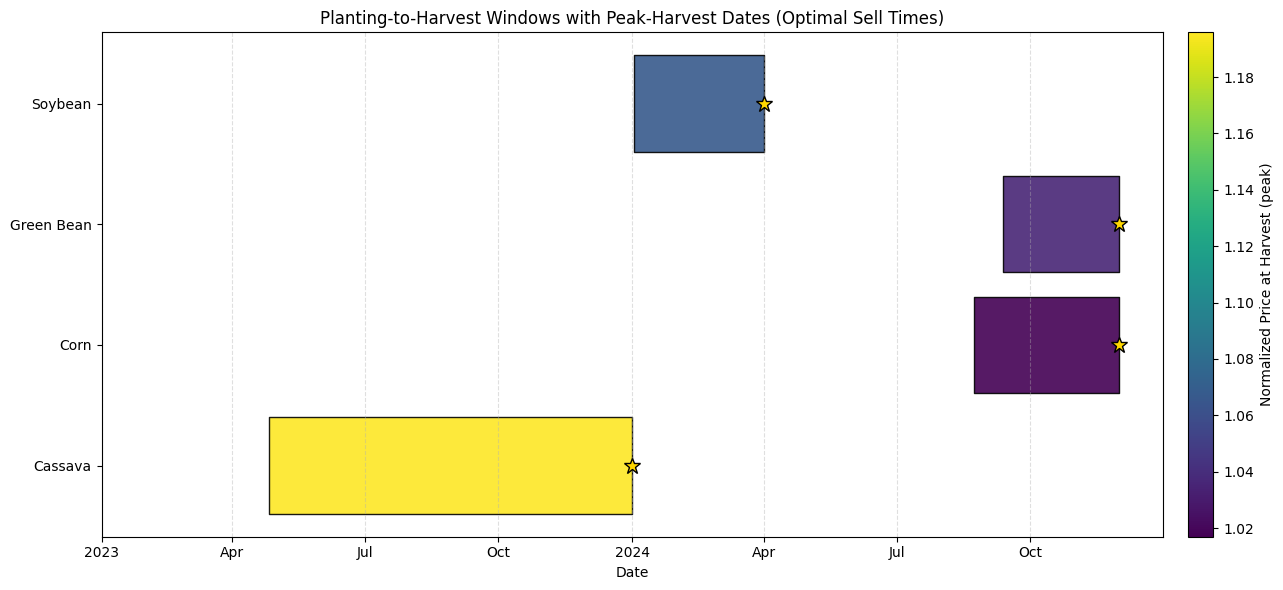


Gantt chart shows 4 planting-to-harvest windows:
Cassava: Plant 2023-04-26, Harvest 2024-01-01 (Price: 1.196)
Corn: Plant 2024-08-23, Harvest 2024-12-01 (Price: 1.017)
Green Bean: Plant 2024-09-12, Harvest 2024-12-01 (Price: 1.036)
Soybean: Plant 2024-01-02, Harvest 2024-04-01 (Price: 1.067)


In [293]:
# Build a Gantt chart of planting-to-harvest aligned with peak prices
from datetime import timedelta
import matplotlib.dates as mdates
import pandas as pd

# 1) Prepare series by crop: ensure datetime and numeric arrays
prepared = {}
for crop, data in crop_data.items():
    dates_raw = data["dates"]
    prices_raw = data["prices"]

    # Parse dates robustly
    dates = pd.to_datetime(pd.Series(dates_raw), errors="coerce")
    prices = pd.to_numeric(pd.Series(prices_raw), errors="coerce")
    mask = dates.notna() & prices.notna() & np.isfinite(prices.values)

    dates = dates[mask].to_list()  # python datetimes
    prices = prices[mask].astype(float).to_numpy()

    if len(dates) >= 3:
        prepared[crop] = (dates, prices)


# 2) Find the single best harvest date per crop (highest price peak)
def find_best_harvest_date(dates_py, prices_np):
    """Find the date with the highest price (best harvest time)"""
    if len(prices_np) == 0:
        return None, None

    # Find the index of the maximum price
    max_idx = np.argmax(prices_np)
    return dates_py[max_idx], float(prices_np[max_idx])


# 3) Build tasks: one bar per crop using the best harvest date
bars = []  # list of dicts: {crop, start_dt, end_dt, peak_price}
for crop, (dates_py, prices_np) in prepared.items():
    if crop not in time_grow:
        continue

    harvest_dt, peak_price = find_best_harvest_date(dates_py, prices_np)
    if harvest_dt is None:
        continue

    grow_days = int(time_grow[crop])
    start_dt = harvest_dt - timedelta(days=grow_days)

    bars.append(
        {
            "crop": crop,
            "start_dt": start_dt,
            "end_dt": harvest_dt,
            "peak_price": peak_price,
        }
    )

if not bars:
    print("No bars to plot (check dates/prices/time_grow).")
else:
    # Compute desired x-range: start 1 year before earliest forecast date
    if prepared:
        all_first_dates = [min(v[0]) for v in prepared.values() if len(v[0])]
        all_last_dates = [max(v[0]) for v in prepared.values() if len(v[0])]
        earliest_forecast_dt = min(all_first_dates)
        latest_forecast_dt = max(all_last_dates)
        latest_bar_end = max(b["end_dt"] for b in bars) if bars else latest_forecast_dt
        x_left = earliest_forecast_dt - pd.Timedelta(days=365)
        x_right = max(latest_forecast_dt, latest_bar_end) + pd.Timedelta(days=30)
    else:
        x_left, x_right = None, None

    # 4) Plot Gantt-like chart
    fig, ax = plt.subplots(figsize=(14, 6))

    # Assign a y-position per crop (use time_grow order for consistency)
    crops_order = [c for c in time_grow.keys() if c in prepared]
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize peak intensities for color scaling
    all_peak_vals = np.array([b["peak_price"] for b in bars])
    vmin, vmax = (
        (float(np.min(all_peak_vals)), float(np.max(all_peak_vals)))
        if len(all_peak_vals)
        else (0.0, 1.0)
    )
    denom = (vmax - vmin) if vmax > vmin else 1.0

    for b in bars:
        y = y_map[b["crop"]]
        start_num = mdates.date2num(b["start_dt"])  # matplotlib date number
        end_num = mdates.date2num(b["end_dt"])  # matplotlib date number
        width = max(end_num - start_num, 0.5)  # ensure visible width

        intensity = (b["peak_price"] - vmin) / denom
        color = plt.cm.viridis(intensity)

        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors="black",
            alpha=0.9,
        )
        # Mark the harvest (peak) date with a star
        ax.plot(
            end_num,
            y,
            marker="*",
            color="gold",
            markersize=12,
            markeredgecolor="black",
            zorder=5,
        )

    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date")
    ax.set_title(
        "Planting-to-Harvest Windows with Peak-Harvest Dates (Optimal Sell Times)"
    )

    # Apply extended x-limits if available
    if x_left is not None and x_right is not None:
        ax.set_xlim(x_left, x_right)

    # Format x-axis dates
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

    # Colorbar for peak price intensity (normalized price)
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Normalized Price at Harvest (peak)")

    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.tight_layout()
    plt.show()

    # Print summary for debugging
    print(f"\nGantt chart shows {len(bars)} planting-to-harvest windows:")
    for b in bars:
        print(
            f"{b['crop']}: Plant {b['start_dt'].strftime('%Y-%m-%d')}, Harvest {b['end_dt'].strftime('%Y-%m-%d')} (Price: {b['peak_price']:.3f})"
        )

### Harvest Income Calculation

Calculate the income from harvest using the formula: `income = yield_per_rai * price * rai`

Where:
- `yield_per_rai` = crop yield per rai (kg/rai)
- `price` = peak harvest price (THB/kg) 
- `rai` = land area (assuming 1 rai per crop)

In [295]:
# Calculate harvest income: income = yield_per_rai * price * rai
# Assuming 1 rai of land per crop

# Convert normalized prices back to actual prices using the original averages
harvest_incomes = {}

print("Harvest Income Calculation:")
print("=" * 50)
print(
    f"{'Crop':<12} {'Yield (kg/rai)':<15} {'Price (THB/kg)':<15} {'Rai':<5} {'Income (THB)':<15}"
)
print("-" * 70)

for bar in bars:
    crop = bar["crop"]
    if crop in crops_yield_per_rai and crop in crop_price_avg:
        # Get yield per rai for this crop
        yield_per_rai = crops_yield_per_rai[crop]

        # Convert normalized peak price back to actual price
        normalized_peak_price = bar["peak_price"]
        actual_peak_price = normalized_peak_price * crop_price_avg[crop]

        # Assume 1 rai of land
        rai = 1

        # Calculate income: yield_per_rai * price * rai
        income = yield_per_rai * actual_peak_price * rai

        harvest_incomes[crop] = {
            "yield_per_rai": yield_per_rai,
            "peak_price": actual_peak_price,
            "rai": rai,
            "income": income,
            "harvest_date": bar["end_dt"],
        }

        print(
            f"{crop:<12} {yield_per_rai:<15} {actual_peak_price:<15.2f} {rai:<5} {income:<15,.2f}"
        )

print("\nSummary:")
print("=" * 30)
total_income = sum(data["income"] for data in harvest_incomes.values())
print(f"Total income from all crops: {total_income:,.2f} THB")
print(f"Average income per crop: {total_income / len(harvest_incomes):,.2f} THB")

# Find the most profitable crop
if harvest_incomes:
    most_profitable = max(harvest_incomes.items(), key=lambda x: x[1]["income"])
    least_profitable = min(harvest_incomes.items(), key=lambda x: x[1]["income"])

    print("\nOptimal harvest schedule:")
    for crop, data in sorted(
        harvest_incomes.items(), key=lambda x: x[1]["harvest_date"]
    ):
        print(
            f"  {crop}: {data['harvest_date'].strftime('%Y-%m-%d')} -> {data['income']:,.2f} THB"
        )

Harvest Income Calculation:
Crop         Yield (kg/rai)  Price (THB/kg)  Rai   Income (THB)   
----------------------------------------------------------------------
Cassava      3500            3.48            1     12,180.00      
Corn         2500            11.41           1     28,525.00      
Green Bean   245             25.52           1     6,252.40       
Soybean      300             19.65           1     5,895.00       

Summary:
Total income from all crops: 52,852.40 THB
Average income per crop: 13,213.10 THB

Optimal harvest schedule:
  Cassava: 2024-01-01 -> 12,180.00 THB
  Soybean: 2024-04-01 -> 5,895.00 THB
  Corn: 2024-12-01 -> 28,525.00 THB
  Green Bean: 2024-12-01 -> 6,252.40 THB


### Optimization: Non-overlapping schedule in 2024 (Scheduling/Knapsack)

We select at most one planting-to-harvest window per crop with harvest in 2024, ensure no overlaps across crops, and maximize total income. We:
- Generate candidate windows from 2024 local peak prices per crop.
- Greedily select highest-income windows that don’t overlap, one per crop.
- Attempt to shift remaining crops into available gaps (still within 2024) by income priority, keeping growth duration constant.
- Plot an optimized Gantt chart and report total optimized income.

### Crop Schedule Optimization System

The current planting and harvesting schedule has overlaps, which isn't practical when using the same land or resources. This optimization system will:

1. Start with the most profitable crops
2. Schedule them to avoid overlapping planting and harvesting windows
3. Try to keep all harvests within 2024
4. Apply a hybrid scheduling/knapsack approach to maximize total income
5. Visualize the optimized schedule in a new Gantt chart

This approach prioritizes the most profitable crops and finds time slots for them while respecting growing times and the 2024 target year.

Crop Schedule Optimization Results
Total crops: 4
Scheduled crops: 4
Excluded crops: 0 

Scheduling strategies used:
  original: 3 crops
  shifted_within_year: 1 crops
  previous_year: 0 crops
  excluded: 0 crops

Total income before optimization: 52,852.40 THB
Total income after optimization: 52,852.40 THB
Optimization impact: 100.0% of original income

Optimized schedule details:
Crop         Plant Date   Harvest Date Strategy             Income (THB)   
----------------------------------------------------------------------
Cassava      2023-04-26   2024-01-01   original             12,180.00
Soybean      2024-01-02   2024-04-01   original             5,895.00
Green Bean   2024-06-04   2024-08-23   shifted_within_year  6,252.40
Corn         2024-08-23   2024-12-01   original             28,525.00


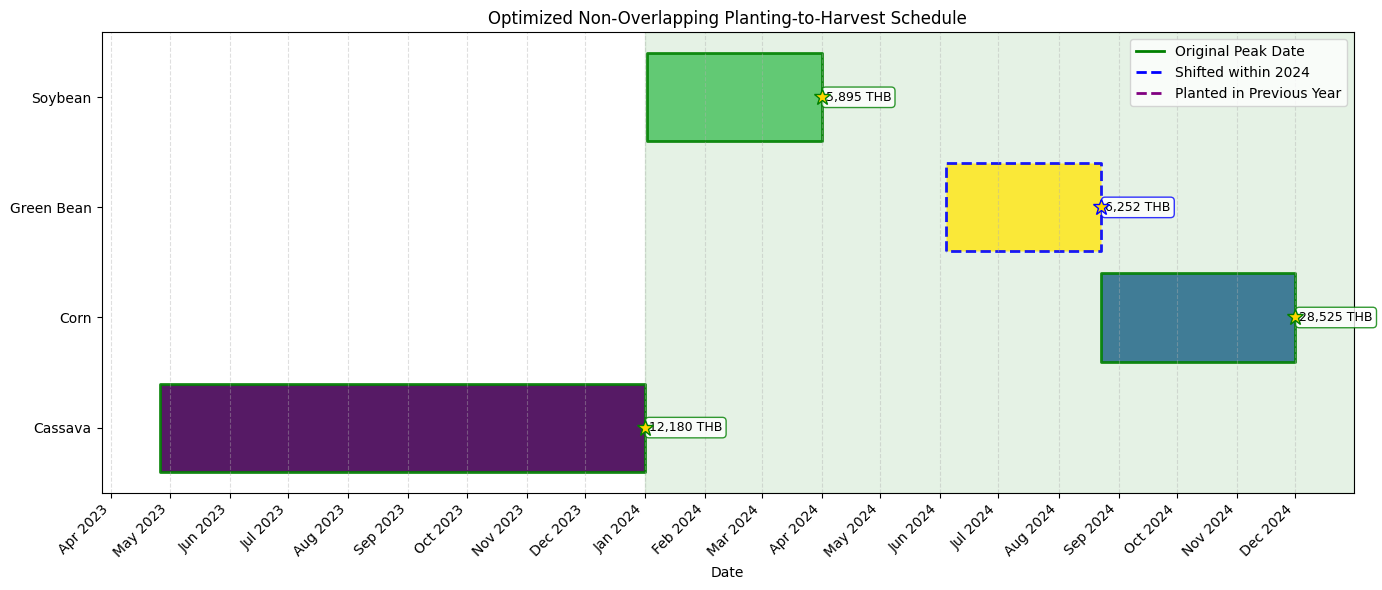


Land Utilization: 89% (523 days with crops / 585 total days)


In [297]:
# Crop Scheduling Optimization
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import date

# Step 1: Create a sorted list of crops by income (descending)
crop_candidates = []
for crop, data in harvest_incomes.items():
    crop_candidates.append(
        {
            "crop": crop,
            "income": data["income"],
            "duration": time_grow[crop],
            "harvest_date": data["harvest_date"],
            "peak_price": data["peak_price"],
        }
    )

# Sort by income, highest first
crop_candidates.sort(key=lambda x: x["income"], reverse=True)

# Define scheduling parameters
year_2024_start = datetime(2024, 1, 1)
year_2024_end = datetime(2024, 12, 31)


# Step 2: Create a schedule optimizer
def find_non_overlapping_schedule(
    candidates, target_year_start=year_2024_start, target_year_end=year_2024_end
):
    """
    Find a non-overlapping schedule for crops, prioritizing by income
    and trying to fit harvests into target year (2024)
    """
    # Start with an empty schedule
    schedule = []
    used_crops = set()

    # Track intervals that are already booked
    intervals = []

    # Strategies count for debugging
    strategy_count = {
        "original": 0,
        "shifted_within_year": 0,
        "previous_year": 0,
        "excluded": 0,
    }

    # Step 3: Try to schedule each crop, starting with most profitable
    for cand in candidates:
        crop = cand["crop"]
        if crop in used_crops:
            continue

        # Original dates from the peak price analysis
        original_harvest = cand["harvest_date"]
        duration = cand["duration"]
        original_plant = original_harvest - timedelta(days=duration)

        # First strategy: Try original dates
        conflict = False
        for start, end in intervals:
            # Check if this interval overlaps with any existing interval
            if not (original_plant >= end or original_harvest <= start):
                conflict = True
                break

        if not conflict:
            # Original dates work! Add to schedule
            intervals.append((original_plant, original_harvest))
            schedule.append(
                {
                    "crop": crop,
                    "start_dt": original_plant,
                    "end_dt": original_harvest,
                    "income": cand["income"],
                    "peak_price": cand["peak_price"],
                    "strategy": "original",
                }
            )
            used_crops.add(crop)
            strategy_count["original"] += 1
            continue

        # Strategy 2: Try to shift within target year while avoiding conflicts
        # Find gaps between scheduled intervals where this crop could fit
        all_within_year = False

        # Find available gaps
        gaps = []
        # Add the gap from start of year to first interval
        if intervals:
            intervals.sort(key=lambda x: x[0])  # Sort by start date
            if intervals[0][0] > target_year_start:
                gaps.append((target_year_start, intervals[0][0]))

            # Add gaps between intervals
            for i in range(len(intervals) - 1):
                if intervals[i + 1][0] - intervals[i][1] >= timedelta(days=duration):
                    gaps.append((intervals[i][1], intervals[i + 1][0]))

            # Add gap from last interval to end of year
            if intervals[-1][1] < target_year_end:
                gaps.append((intervals[-1][1], target_year_end))
        else:
            # If no intervals yet, the entire year is available
            gaps.append((target_year_start, target_year_end))

        # Try to place in gaps, preferring gaps that allow harvest in 2024
        placed = False
        for g_start, g_end in gaps:
            # Try to fit the crop in this gap
            if g_end - g_start >= timedelta(days=duration):
                # Can fit! Try to position for harvest in 2024 if possible
                end_candidate = min(g_end, target_year_end)
                start_candidate = end_candidate - timedelta(days=duration)

                # Check if start date is after gap start
                if start_candidate >= g_start:
                    schedule.append(
                        {
                            "crop": crop,
                            "start_dt": start_candidate,
                            "end_dt": end_candidate,
                            "income": cand["income"],
                            "peak_price": cand["peak_price"],
                            "strategy": "shifted_within_year",
                        }
                    )
                    intervals.append((start_candidate, end_candidate))
                    used_crops.add(crop)
                    strategy_count["shifted_within_year"] += 1
                    placed = True
                    break

        if placed:
            continue

        # Strategy 3: Allow planting in previous year for long-duration crops
        # Try the largest gap, but allow start_dt to be before 2024
        if gaps:
            # Find the largest gap
            largest_gap = max(gaps, key=lambda x: x[1] - x[0])
            g_start, g_end = largest_gap

            # Try to place with harvest in 2024
            end_candidate = min(g_end, target_year_end)
            start_candidate = end_candidate - timedelta(days=duration)

            # Even if start is before 2024, add if harvest is in 2024
            if end_candidate <= target_year_end and end_candidate >= target_year_start:
                schedule.append(
                    {
                        "crop": crop,
                        "start_dt": start_candidate,
                        "end_dt": end_candidate,
                        "income": cand["income"],
                        "peak_price": cand["peak_price"],
                        "strategy": "previous_year",
                    }
                )
                intervals.append((start_candidate, end_candidate))
                used_crops.add(crop)
                strategy_count["previous_year"] += 1
                continue

        # If we get here, we couldn't schedule this crop
        strategy_count["excluded"] += 1

    return schedule, strategy_count


# Step 4: Run the optimization
optimized_schedule, strategy_stats = find_non_overlapping_schedule(crop_candidates)

# Check what crops were included/excluded
all_crops = set([c["crop"] for c in crop_candidates])
scheduled_crops = set([s["crop"] for s in optimized_schedule])
excluded_crops = all_crops - scheduled_crops

# Calculate total income with optimized schedule
total_optimized_income = sum(item["income"] for item in optimized_schedule)
total_original_income = sum(c["income"] for c in crop_candidates)

# Report results
print(f"Crop Schedule Optimization Results")
print("=" * 50)
print(f"Total crops: {len(crop_candidates)}")
print(f"Scheduled crops: {len(optimized_schedule)}")
print(
    f"Excluded crops: {len(excluded_crops)} {list(excluded_crops) if excluded_crops else ''}"
)
print("\nScheduling strategies used:")
for strategy, count in strategy_stats.items():
    print(f"  {strategy}: {count} crops")

print(f"\nTotal income before optimization: {total_original_income:,.2f} THB")
print(f"Total income after optimization: {total_optimized_income:,.2f} THB")
print(
    f"Optimization impact: {100 * total_optimized_income / total_original_income:.1f}% of original income"
)

print("\nOptimized schedule details:")
print(
    f"{'Crop':<12} {'Plant Date':<12} {'Harvest Date':<12} {'Strategy':<20} {'Income (THB)':<15}"
)
print("-" * 70)
for item in sorted(optimized_schedule, key=lambda x: x["end_dt"]):
    print(
        f"{item['crop']:<12} {item['start_dt'].strftime('%Y-%m-%d'):<12} {item['end_dt'].strftime('%Y-%m-%d'):<12} {item['strategy']:<20} {item['income']:,.2f}"
    )

# Step 5: Visualize the optimized schedule in a Gantt chart
optimized_bars = optimized_schedule

if optimized_bars:
    # Set the x-axis range from start of earliest planting to end of latest harvest
    schedule_span_start = min(b["start_dt"] for b in optimized_bars) - timedelta(
        days=30
    )
    schedule_span_end = max(b["end_dt"] for b in optimized_bars) + timedelta(days=30)

    # Create the Gantt chart
    fig, ax = plt.subplots(figsize=(14, 6))

    # Assign a y-position per crop (alphabetical for consistency)
    crops_order = sorted(list(set([b["crop"] for b in optimized_bars])))
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize peak intensities for color scaling
    all_peak_vals = np.array([float(b["peak_price"]) for b in optimized_bars])
    vmin, vmax = (
        (float(np.min(all_peak_vals)), float(np.max(all_peak_vals)))
        if len(all_peak_vals)
        else (0.0, 1.0)
    )
    denom = (vmax - vmin) if vmax > vmin else 1.0

    # Color coding for different strategies
    strategy_colors = {
        "original": "green",
        "shifted_within_year": "blue",
        "previous_year": "purple",
    }

    # Draw a semi-transparent overlay for 2024
    year_2024_start_num = mdates.date2num(year_2024_start)
    year_2024_end_num = mdates.date2num(year_2024_end)
    ax.axvspan(
        year_2024_start_num,
        year_2024_end_num,
        alpha=0.1,
        color="green",
        zorder=0,
        label="Target Year (2024)",
    )

    for b in optimized_bars:
        y = y_map[b["crop"]]
        start_num = mdates.date2num(b["start_dt"])
        end_num = mdates.date2num(b["end_dt"])
        width = max(end_num - start_num, 0.5)  # ensure visible width

        # Edge color based on strategy
        edge_color = strategy_colors.get(b["strategy"], "black")
        edge_style = "-" if b["strategy"] == "original" else "--"

        # Color by price (higher prices = warmer colors)
        intensity = (float(b["peak_price"]) - vmin) / denom if denom else 0.5
        color = plt.cm.viridis(intensity)

        # Draw bar
        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors=edge_color,
            linestyles=edge_style,
            linewidth=2,
            alpha=0.9,
        )

        # Mark the harvest date with a star
        ax.plot(
            end_num,
            y,
            marker="*",
            color="gold",
            markersize=12,
            markeredgecolor=edge_color,
            zorder=5,
        )

        # Add crop name and income label
        ax.text(
            end_num + 2,
            y,
            f"{b['income']:,.0f} THB",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=edge_color, alpha=0.8),
        )

    # Configure the chart
    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date")
    ax.set_title("Optimized Non-Overlapping Planting-to-Harvest Schedule")

    # Set the x-axis range
    ax.set_xlim(schedule_span_start, schedule_span_end)

    # Format x-axis dates
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45, ha="right")

    # Add target year highlighting label to legend
    handles, labels = ax.get_legend_handles_labels()

    # Create legend entries for strategies
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            color=strategy_colors["original"],
            lw=2,
            linestyle="-",
            label="Original Peak Date",
        ),
        Line2D(
            [0],
            [0],
            color=strategy_colors["shifted_within_year"],
            lw=2,
            linestyle="--",
            label="Shifted within 2024",
        ),
        Line2D(
            [0],
            [0],
            color=strategy_colors["previous_year"],
            lw=2,
            linestyle="--",
            label="Planted in Previous Year",
        ),
    ]

    ax.legend(handles=legend_elements, loc="upper right")

    # Add grid and show
    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.tight_layout()
    plt.show()

    # Calculate land utilization (% of year used for crops)
    earliest_start = min(b["start_dt"] for b in optimized_bars)
    latest_end = max(b["end_dt"] for b in optimized_bars)
    total_days = (latest_end - earliest_start).days

    # Calculate how many days had at least one crop growing
    dates = []
    for b in optimized_bars:
        # Add all days from start to end for this crop
        current = b["start_dt"]
        while current <= b["end_dt"]:
            dates.append(current.date())
            current += timedelta(days=1)

    # Count unique dates
    unique_dates = len(set(dates))
    utilization = int(100 * unique_dates / total_days)

    print(
        f"\nLand Utilization: {utilization}% ({unique_dates} days with crops / {total_days} total days)"
    )
else:
    print("No crops were scheduled. Check the constraints and data.")